In [1]:
import os

os.chdir("../..")

In [2]:
import pandas as pd
import numpy as np
from data.data import get_hiv_data, get_hiv_clf
#from src.e_crt import EcrtTester
#from src.sampling_functions import sample_hiv_data
#from src.utils import TanhBet, get_martingale_values

In [3]:
np.random.seed(0)
j_vec = [10, 61, 62]
batch_list = [5, 10, 20]
n_init = 800
#offline=True
#g_func = TanhBet()
#sampling_func = sample_hiv_data
#save_path = "./results/HIV"
X, Y, features_names = get_hiv_data()

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

models = {
    "Ridge (L2 linear)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # safe for sparse/binary-like data
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso (L1 linear)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("model", Lasso(alpha=0.001, max_iter=5000))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        random_state=42
    ),

    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        Y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": scores["test_r2"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "MAE": -scores["test_mae"].mean()
    })

df_results = pd.DataFrame(results).sort_values("R2", ascending=False)
print(df_results.round(4))

/home/michele/.venvs/modelX/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/michele/.venvs/modelX/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/michele/.venvs/modelX/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/michele/.venvs/modelX/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was exp

                    Model      R2    RMSE     MAE
1       Lasso (L1 linear)  0.8820  0.3013  0.2220
0       Ridge (L2 linear)  0.8796  0.3043  0.2241
3       Gradient Boosting  0.8699  0.3166  0.2337
4  Hist Gradient Boosting  0.8627  0.3254  0.2348
2           Random Forest  0.8412  0.3499  0.2541
5    Neural Network (MLP)  0.7433  0.4443  0.3309


In [5]:
os.chdir("src")

In [6]:
from copy import deepcopy

from ML_e_process import ML_e_process
from sklearn.linear_model import LassoCV
from Sampler import DefaultSampler
from ExponentialBet import ExponentialBet  
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_exponential_parameters, prepare_coin_betting_parameters, g_family_cb, update_g_func_static, prepare_lambda_parameters, g_family_tanh, g_family_sign, prepare_kernel_density_parameters, g_family_kde, generate_update_kde, initialize_kde_history


etas = prepare_exponential_parameters(0.01, 5, 10)
strategy_exp = ExponentialBet(
    parameters=etas,
    exact=True
)

params_cb = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy_cb = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params_cb,
)


params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 0.95, lam_num = 10)

strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)

strategy_sign_preq = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


betting_strategies = {
    "exponential": strategy_exp,
    "coin_betting": strategy_cb,
    "tanh": strategy_tanh,
    "sign": strategy_sign,
    "sign_preq": strategy_sign_preq,
}
### This function generates a KDE updater, which specifies how many times are we going at most to repeat a q
### when training the KDE, and the window size, which can be *None* for no windowing  

resamplings = 1
window_size = None
updater_kde = generate_update_kde(resamplings=resamplings, window_size=window_size, one_dimensional=True)
bets_js_bs = {
            j: {
                b: {
                    key: deepcopy(strategy)
                    for key, strategy in betting_strategies.items()
                }
                for b in batch_list
            }
            for j in j_vec
        }
sampdoria = [DefaultSampler(j=j) for j in j_vec]
q, q_tilde = initialize_kde_history(X[:n_init], Y[:n_init].ravel(), sampdoria, j_vec, batch_list, model = LassoCV(), resamplings=resamplings)
for j in j_vec:
    for b in batch_list:
        params_kde = prepare_kernel_density_parameters()
        model_for_history = model
        sampdoria = [DefaultSampler(j=j)]
        
        past_qs = list(zip(q[b], q_tilde[b][j]))
        strategy_kde = AntisymmetricBet(
            g_family= g_family_kde, 
            update_g_func = updater_kde, 
            parameters=params_kde,
            prequential=True,
            past_qs = past_qs
        )
        bets_js_bs[j][b]["kde"] = strategy_kde


#batch_list = [1, 2, 5]
e_process = ML_e_process(batch_list=batch_list, n_init=n_init, b_resamplings=1, study_j=j_vec,
                 betting_strategies=betting_strategies, model=LassoCV(),
                 #learn_conditional_distribution=get_data_statistics,
                 samplers=None, #sampling_args={}
                 learn_conditional_distribution=True,
                 optional_stopping=True, 
                 bets_js_bs=bets_js_bs
                 )


In [7]:
n_init

800

In [8]:
martingales = e_process.martingales(X, y=Y)

In [9]:
martingales.keys()

dict_keys(['exponential', 'coin_betting', 'tanh', 'sign', 'sign_preq', 'kde'])

In [10]:
import pickle

with open("martingales_batch_size_1.pkl", "wb") as f:
    pickle.dump(martingales, f)

##Loading saved martingales

In [11]:
import pickle as pkl

martingales = pkl.load(open("martingales_batch_size_1.pkl", "rb"))


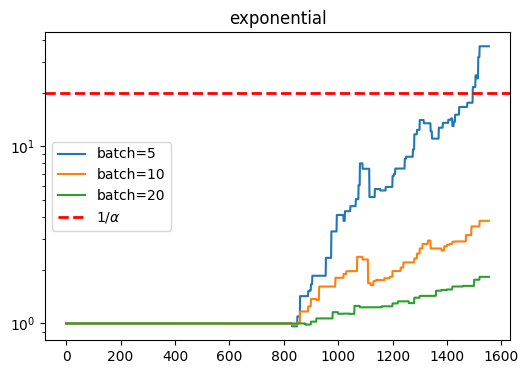

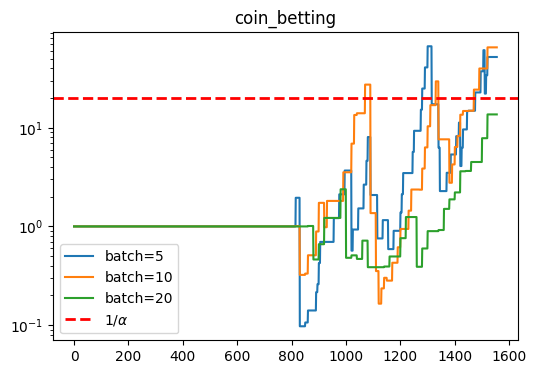

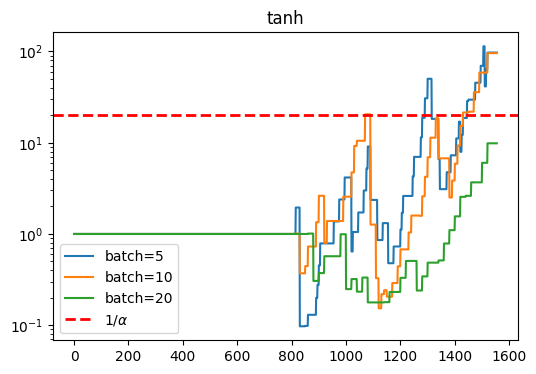

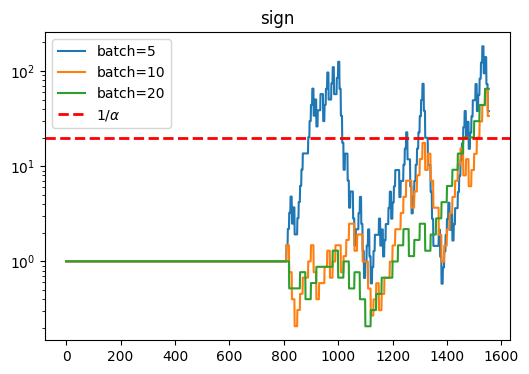

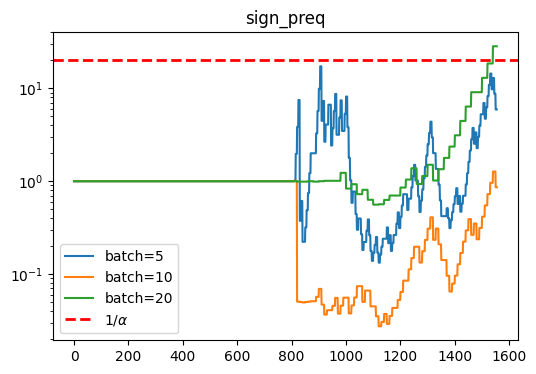

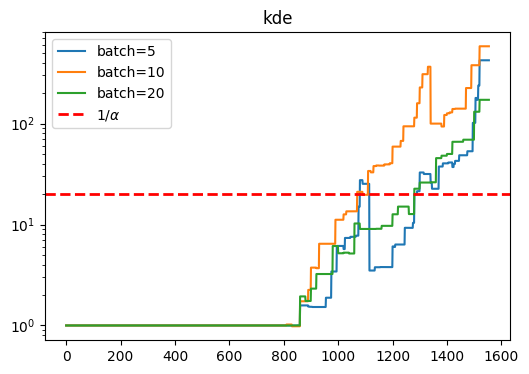

In [12]:
import matplotlib.pyplot as plt
alpha = 0.05
j = 61 #j_vec = [10, 61, 62]
for strategy_name in martingales.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()

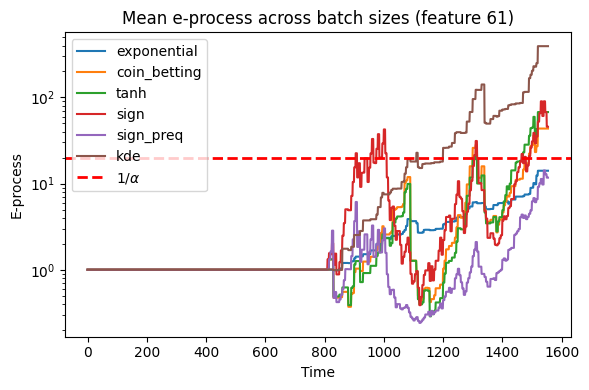

In [13]:
import numpy as np

plt.figure(figsize=(6, 4))

for strategy_name in martingales.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

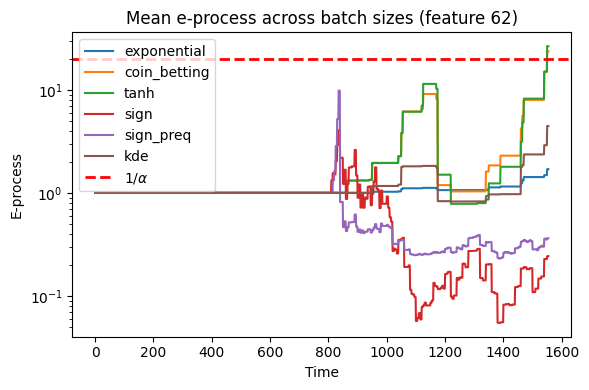

In [14]:
j = 62

plt.figure(figsize=(6, 4))

for strategy_name in martingales.keys():
    mean_process = np.mean(
        [martingales[strategy_name][b][j] for b in batch_list],
        axis=0
    )

    plt.plot(mean_process, label=strategy_name)

plt.axhline(
    y=1 / alpha,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$1/\alpha$"
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("E-process")
plt.title(f"Mean e-process across batch sizes (feature {j})")
plt.legend()
plt.tight_layout()
plt.show()

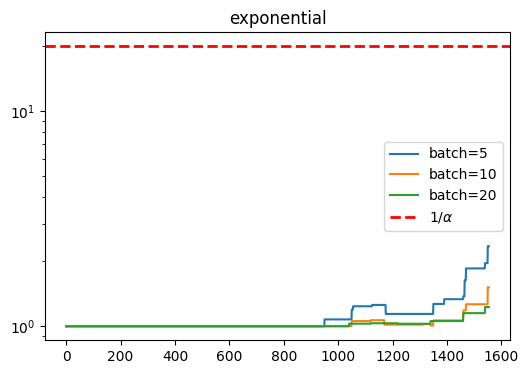

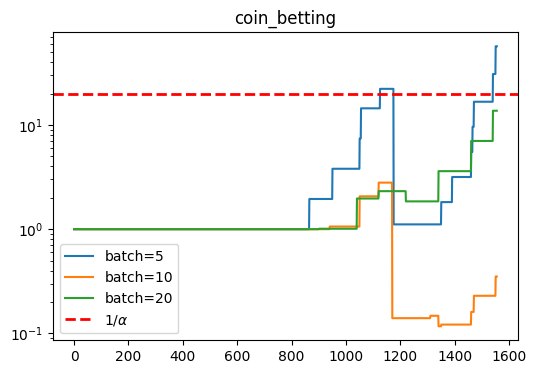

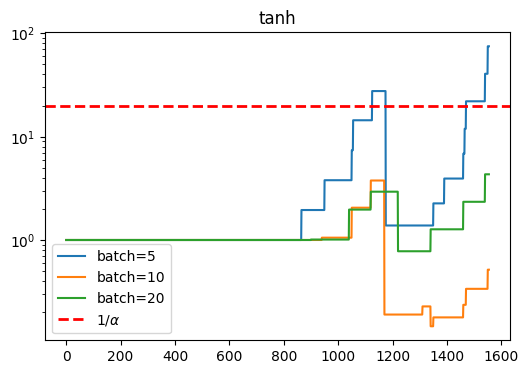

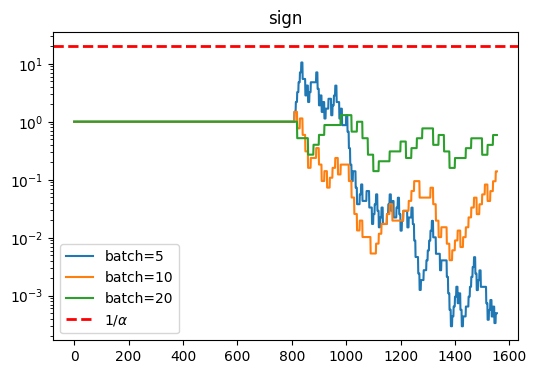

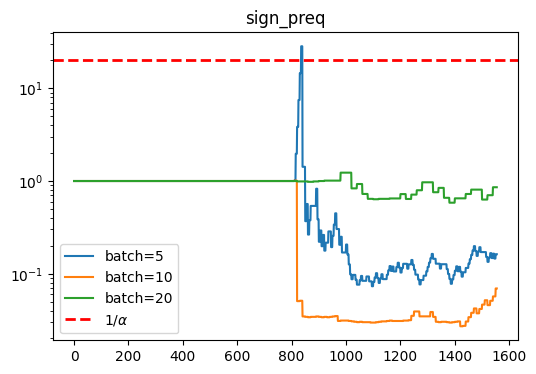

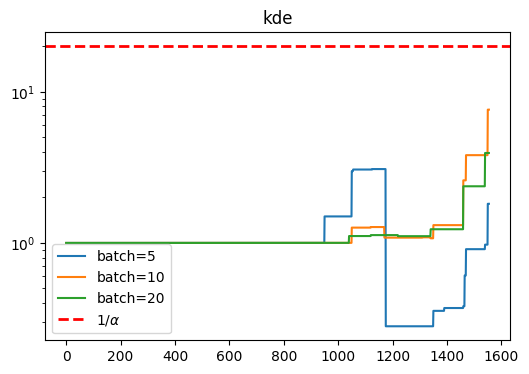

In [15]:
for strategy_name in martingales.keys():
    plt.figure(figsize=(6, 4))
    for b in batch_list:
        plt.plot(
            martingales[strategy_name][b][j],
            label=f"batch={b}"
        )
    plt.yscale("log")
    plt.title(strategy_name)
    plt.axhline(
        y=1/alpha,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$1/\alpha$"
    )
    plt.legend()
    plt.show()